Importem les llibreries i els conjunts de dades que necessitarem

In [2]:
import pandas as pd
import numpy as np
clients=pd.read_csv('abandonament-telecom/clients.csv')
abandonament=pd.read_csv('abandonament-telecom/abandonament.csv')
internet=pd.read_csv('abandonament-telecom/internet.csv')

# unim les taules de dades en una i traiem la columna customerID pq és redundant
df=clients.merge(abandonament, on='customerID', how='outer') # unim
df=df.merge(internet, on='customerID', how='outer')
df.drop('customerID',axis=1,inplace=True)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,Female,0,Yes,Yes,9,Yes,One year,Yes,Mailed check,65.60,,No,No,DSL,No,Yes,No,Yes,Yes,No
1,Male,0,No,No,9,Yes,Month-to-month,No,Mailed check,59.90,542.4,No,Yes,DSL,No,No,No,No,No,Yes
2,Male,0,No,No,4,Yes,Month-to-month,Yes,Electronic check,73.90,280.85,Yes,No,Fiber optic,No,No,Yes,No,No,No
3,Male,1,Yes,No,13,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes
4,Female,1,Yes,No,3,Yes,Month-to-month,Yes,Mailed check,83.90,267.4,Yes,No,Fiber optic,No,No,No,Yes,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,Female,0,No,No,13,Yes,One year,No,Mailed check,55.15,742.9,No,No,DSL,Yes,No,No,Yes,No,No
7038,Male,0,Yes,No,22,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7,Yes,Yes,Fiber optic,No,No,No,No,No,Yes
7039,Male,0,No,No,2,Yes,Month-to-month,Yes,Mailed check,50.30,,No,No,DSL,No,Yes,No,No,No,No
7040,Male,0,Yes,Yes,67,Yes,Two year,No,Mailed check,67.85,4627.65,No,No,DSL,Yes,No,Yes,Yes,No,Yes


Processem les dades per a que siguin aptes per al model, convertim les variables categòriques a numèriques.

In [4]:
# el Churn serà paràmetre que voldrem predir, l'assgnem a la variable y
y=df['Churn'].map({'No':0, 'Yes':1})

# la resta de columnes seran les candidates a fer de predictors
# convertim les variables categòriques binàries a numériques, més endavant processarem la resta de variables més complicades
X = pd.DataFrame({
    'gender': df['gender'].map({'Female': 0, 'Male': 1}),
    'SeniorCitizen': df['SeniorCitizen'],
    'Partner': df['Partner'],
    'Dependents': df['Dependents'].map({'No': 0, 'Yes': 1}),
    'tenure': df['tenure'],
    'PhoneService': df['PhoneService'].map({'No': 0, 'Yes': 1}),
    'Contract': df['Contract'],
    'PaperlessBilling': df['PaperlessBilling'].map({'No': 0, 'Yes': 1}),
    'PaymentMethod': df['PaymentMethod'],
    'MonthlyCharges': df['MonthlyCharges'],
    'MultipleLines': df['MultipleLines'],
    'InternetService': df['InternetService'],
    'OnlineSecurity': df['OnlineSecurity'].map({'No': 0, 'No internet service': 0,'Yes': 1}), # considerem 'No internet service' com a 'No'
    'OnlineBackup': df['OnlineBackup'].map({'No': 0, 'No internet service': 0,'Yes': 1}),
    'DeviceProtection': df['DeviceProtection'].map({'No': 0, 'No internet service': 0,'Yes': 1}),
    'TechSupport': df['TechSupport'].map({'No': 0, 'No internet service': 0,'Yes': 1}),
    'StreamingTV': df['StreamingTV'].map({'No': 0, 'No internet service': 0,'Yes': 1}),
    'StreamingMovies': df['StreamingMovies'].map({'No': 0, 'No internet service': 0,'Yes': 1}),
    'TotalCharges': df['MonthlyCharges'] * df['tenure'] # reemplacem la columna 'TotalCharges' per el que paguen al mes multiplicat pels mesos
})
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,TotalCharges
0,0,0,Yes,1,9,1,One year,1,Mailed check,65.60,No,DSL,0,1,0,1,1,0,590.40
1,1,0,No,0,9,1,Month-to-month,0,Mailed check,59.90,Yes,DSL,0,0,0,0,0,1,539.10
2,1,0,No,0,4,1,Month-to-month,1,Electronic check,73.90,No,Fiber optic,0,0,1,0,0,0,295.60
3,1,1,Yes,0,13,1,Month-to-month,1,Electronic check,98.00,No,Fiber optic,0,1,1,0,1,1,1274.00
4,0,1,Yes,0,3,1,Month-to-month,1,Mailed check,83.90,No,Fiber optic,0,0,0,1,1,0,251.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,0,0,No,0,13,1,One year,0,Mailed check,55.15,No,DSL,1,0,0,1,0,0,716.95
7038,1,0,Yes,0,22,1,Month-to-month,1,Electronic check,85.10,Yes,Fiber optic,0,0,0,0,0,1,1872.20
7039,1,0,No,0,2,1,Month-to-month,1,Mailed check,50.30,No,DSL,0,1,0,0,0,0,100.60
7040,1,0,Yes,1,67,1,Two year,0,Mailed check,67.85,No,DSL,1,0,1,1,0,1,4545.95


Normalitzem les variables numériques i transformem les variables categòriques q tenen mes de 2 valors

In [6]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X['MonthlyCharges_scaled'] = scaler.fit_transform(X[['MonthlyCharges']])
X['tenure_scaled'] = scaler.fit_transform(X[['tenure']])
X['TotalCharges_scaled'] = scaler.fit_transform(X[['TotalCharges']])
X.drop('MonthlyCharges', axis=1, inplace=True)
X.drop('tenure', axis=1, inplace=True)
X.drop('TotalCharges', axis=1, inplace=True)

# Com que Partner te valors nan's l'haurem de transformar per separat pq sino pandas no llegeix aquests valors
# per a simplificar les dades eliminem una de les columnes que crea .get_dummies() amb drop_first=True pq és redundant. Per una columna amb k valors, crearà k-1 columnes binàries
X=pd.get_dummies(X, columns=['Partner'],dummy_na=True, dtype=int)
X=pd.get_dummies(X, columns=['Contract','PaymentMethod','MultipleLines','InternetService'],dtype=int)
X['TotalServeis'] = X['OnlineSecurity'] + X['OnlineBackup'] + X['DeviceProtection'] + X['TechSupport'] + X['StreamingTV'] + X['StreamingMovies'] + X['InternetService_Fiber optic'] + X['InternetService_DSL']
X

,gender,SeniorCitizen,Dependents,PhoneService,PaperlessBilling,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,TotalServeis
0,0,0,1,1,1,0,1,0,1,1,...,0,0,1,1,0,0,1,0,0,4
1,1,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,1,1,0,0,2
2,1,0,0,1,1,0,0,1,0,0,...,0,1,0,1,0,0,0,1,0,2
3,1,1,0,1,1,0,1,1,0,1,...,0,1,0,1,0,0,0,1,0,5
4,0,1,0,1,1,0,0,0,1,1,...,0,0,1,1,0,0,0,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,0,0,0,1,0,1,0,0,1,0,...,0,0,1,1,0,0,1,0,0,3
7038,1,0,0,1,1,0,0,0,0,0,...,0,1,0,0,0,1,0,1,0,2
7039,1,0,0,1,1,0,1,0,0,0,...,0,0,1,1,0,0,1,0,0,2
7040,1,0,1,1,0,1,0,1,1,0,...,0,0,1,1,0,0,1,0,0,5


Creem el model de regressió lineal i l'entrenem amb les dades que hem processat (X_train i y_train)

Els diferents paràmetres que podem variar son:

max_iter
penalty: 'l1', 'l2', 'elasticnet',  (elasticnet combina l1 i l2, segons la proporció l1_ratio)
solver: podem escollir-lo depenent de la penalització que triem

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score

X_train=pd.read_csv('X_train.csv')
X_test=pd.read_csv('X_test.csv')
y_train=pd.read_csv('y_train.csv')
y_test=pd.read_csv('y_test.csv')

y_train=y_train.values.flatten() # aqui canviem la dimensió de la taula que s'importa a un array perque sino ens surten warnings al entrenar el model
y_test=y_test.values.flatten()

Entrenem el model diverses vegades canviant el paràmetre C que controla la regularització: quant confia el model en les dades d’entrenament que li proporcionem. C petit = model més prudent, C gran = model que confia més en les dades d’entrenament.

In [10]:
provar=[0.001,0.01,0.1,1,10,100,1000,10000]

for prova in provar:
    model = LogisticRegression(max_iter=10000, C=prova)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    
    #mirem l'exactitud i el recall per tenir un bon enteniment del rendiment del model
    exactitud = round(model.score(X_test,y_test)*100,10)
    recall=recall_score(y_test,y_pred)
    print(f"{prova}->Exactitud: {exactitud}, recall: {recall}")

0.001->Exactitud: 73.4563520227, recall: 0.0
0.01->Exactitud: 78.6373314407, recall: 0.36363636363636365
0.1->Exactitud: 79.3470546487, recall: 0.4786096256684492
1->Exactitud: 79.2760823279, recall: 0.48663101604278075
10->Exactitud: 79.6309439319, recall: 0.5026737967914439
100->Exactitud: 79.6309439319, recall: 0.5026737967914439
1000->Exactitud: 79.6309439319, recall: 0.5026737967914439
10000->Exactitud: 79.6309439319, recall: 0.5026737967914439


In [11]:
# provant he trobat que aquests paràmetres maximitzen l'exactitud de les prediccions
model = LogisticRegression(max_iter=10000, random_state=5, C=10)
model.fit(X_train, y_train)

# Fem les prediccions respecte les dades de test, que el model no ha vist
y_pred = model.predict(X_test)

Obtenim els següents resultats

In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



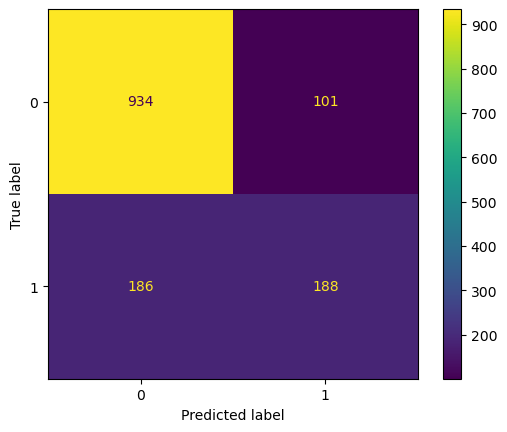

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

In [15]:
# mirem quina importància té cada variable predictora sobre el model
feature_names = X_train.columns
coefficients = model.coef_[0]
feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
print(feature_importance.sort_values(by='Coefficient', ascending=False))

                                  Feature  Coefficient
13                    totalcharges_scaled     1.799931
23            InternetService_Fiber optic     0.777226
19         PaymentMethod_Electronic check     0.354510
4                        PaperlessBilling     0.338620
10                        StreamingMovies     0.253895
1                           SeniorCitizen     0.238868
22                      MultipleLines_Yes     0.221323
9                             StreamingTV     0.146031
21         MultipleLines_No phone service     0.142627
11                  monthlycharges_scaled     0.097847
20             PaymentMethod_Mailed check    -0.005666
0                                  gender    -0.014053
7                        DeviceProtection    -0.031420
14                            Partner_Yes    -0.044707
18  PaymentMethod_Credit card (automatic)    -0.045212
6                            OnlineBackup    -0.118234
2                              Dependents    -0.118504
15        

Provem si eliminant les variables predictores que tenen menys pes a la regressió logística obtenim un rendiment igual o millor

In [17]:
X_train1 = X_train.copy()
X_train1.drop('DeviceProtection',axis=1,inplace=True)
X_train1.drop('gender',axis=1,inplace=True)
X_train1.drop('Partner_Yes',axis=1,inplace=True)
X_train1.drop('PaymentMethod_Mailed check',axis=1,inplace=True)

X_test1 = X_test.copy()
X_test1.drop('DeviceProtection',axis=1,inplace=True)
X_test1.drop('gender',axis=1,inplace=True)
X_test1.drop('Partner_Yes',axis=1,inplace=True)
X_test1.drop('PaymentMethod_Mailed check',axis=1,inplace=True)

In [18]:
model = LogisticRegression(max_iter=10000, random_state=5, C=10)
model.fit(X_train1, y_train)

# Fem les prediccions respecte les dades de test, que el model no ha vist
y_pred = model.predict(X_test1)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



Veiem com el model empitjora lleugerament la seva capacitat de predir

In [31]:
X_train

,gender,SeniorCitizen,Dependents,PhoneService,PaperlessBilling,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,Partner_nan,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No
0,0,1,0,1,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,0,0,0,1,1,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
2,0,0,0,1,0,1,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,1,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,1,0,1,1,1,0,0,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5628,0,0,1,1,1,0,0,0,0,0,...,0,1,0,1,0,0,0,1,0,1
5629,0,0,0,1,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
5630,0,0,0,1,1,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,1
5631,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1
